In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    dpi_save=400,
    figsize=(6,6),
    format='png'
)

In [2]:
adata = sc.read_h5ad('../../data/figure-inputs/scrna_objects/pretx-plasma-paga.h5ad')

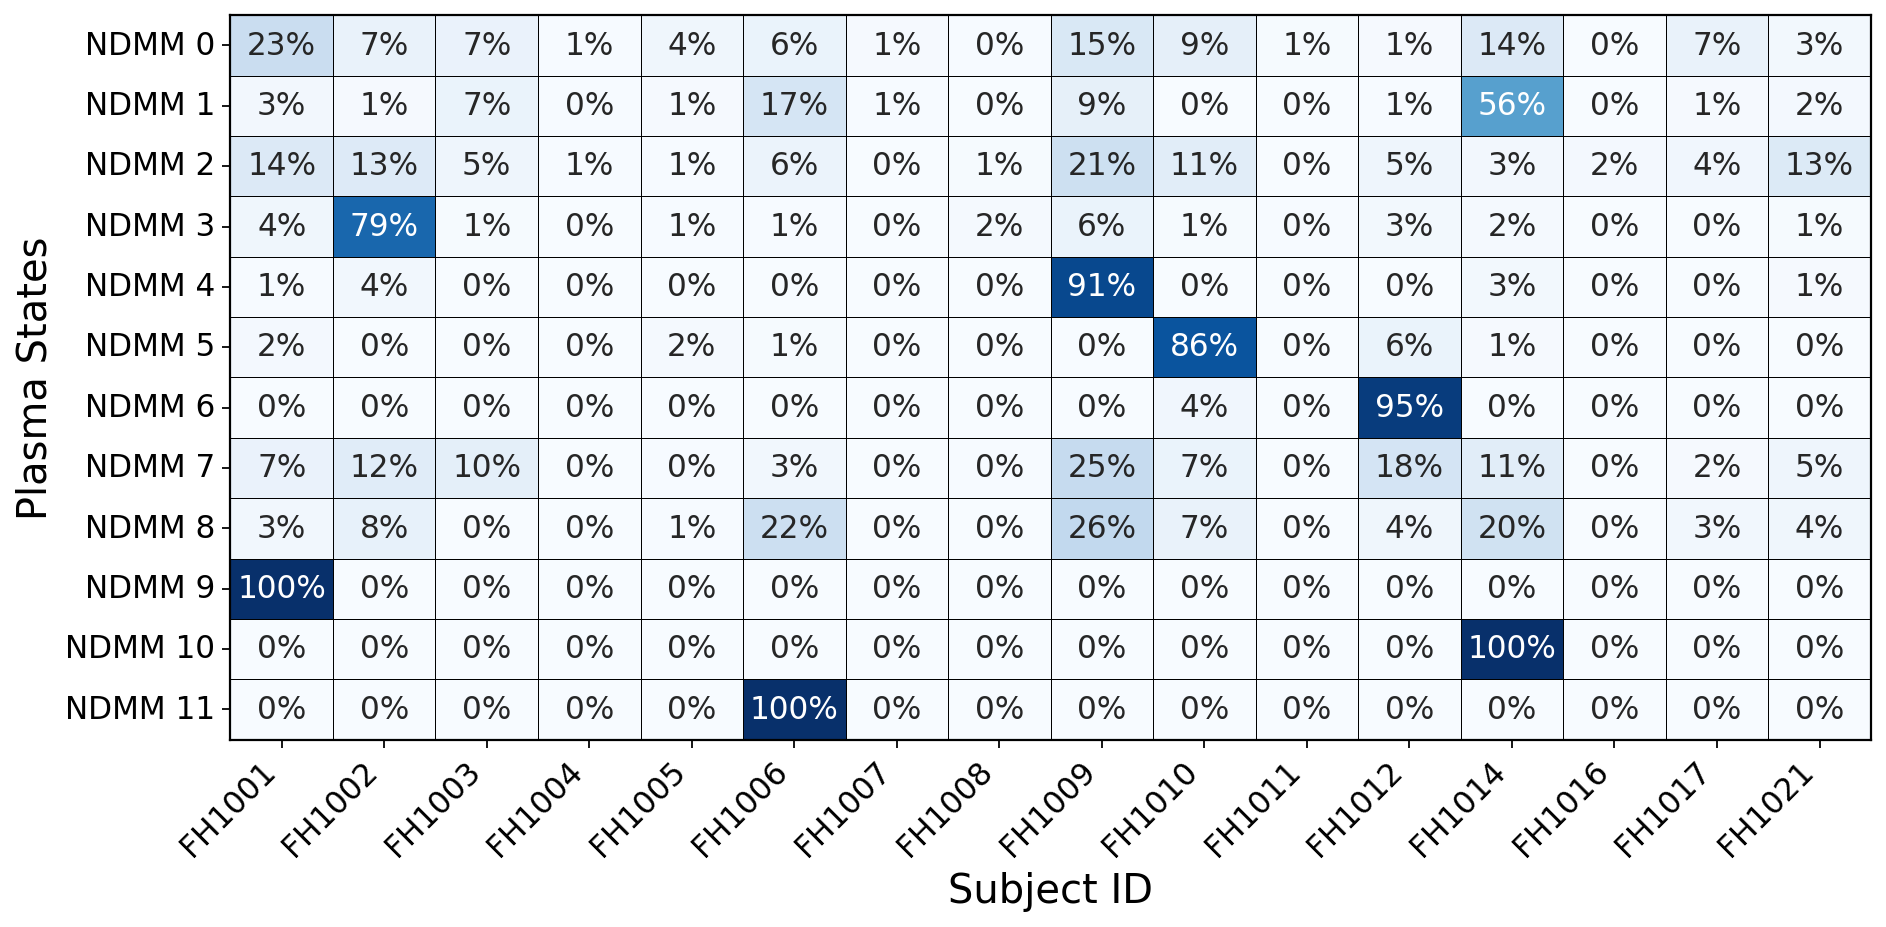

In [3]:
ct = pd.crosstab(adata.obs['plasma_labels_l3'], 
                 adata.obs['subject.subjectGuid'], normalize='index')
plt.rcParams["pdf.fonttype"] = 42
# Create heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct, cmap='Blues', annot=True, fmt='.0%', 
            linewidths=0.3, linecolor='black', cbar=False,
            annot_kws={'fontsize': 14}, ax=ax)

# Add border around entire heatmap
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)
    spine.set_visible(True)

ax.set_xlabel('Subject ID', fontsize=18)
ax.set_ylabel('Plasma States', fontsize=18)
# ax.set_title('Plasma State Distribution by Patient (PreTx)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)
# Remove grid
plt.grid(False)
plt.tight_layout()

plt.savefig('../../data/figure-outputs/supplementary-1/sup_1c.pdf', format='pdf', dpi=200, bbox_inches='tight')